In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file(r"C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\23-5-26\SHP FILE FORMED")
gdf.head()

,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,mean_value,min_value,max_value,geometry
0,Adilabad,Andhra Pradesh,28,1,532,6.529690,0.0,60.000000,"POLYGON ((78.84972 19.7601, 78.85102 19.75945,..."
1,Agra,Uttar Pradesh,9,15,146,2.728956,0.0,51.683168,"POLYGON ((78.19803 27.4028, 78.19804 27.40278,..."
2,Ahmadabad,Gujarat,24,7,474,7.783338,0.0,60.000000,"MULTIPOLYGON (((72.03456 23.50527, 72.03337 23..."
3,Ahmadnagar,Maharashtra,27,26,522,1.837230,0.0,60.000000,"POLYGON ((74.67333 19.9467, 74.67393 19.93509,..."
4,Aizawl,Mizoram,15,3,283,53.259063,0.0,55.841584,"POLYGON ((92.98749 24.40453, 92.99107 24.40236..."


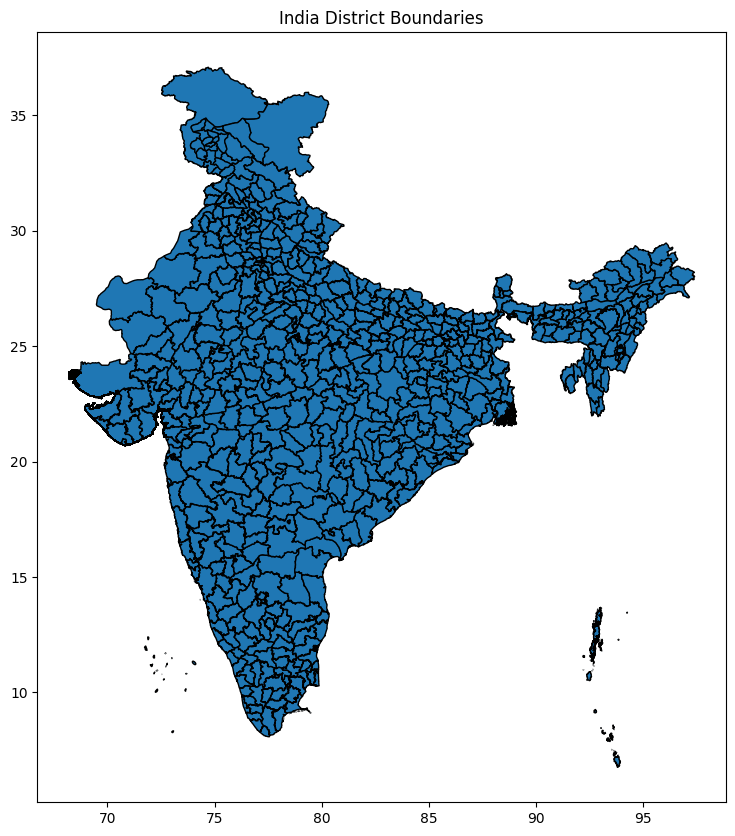

In [2]:
gdf.plot(
    figsize=(10,10),
    edgecolor="black"
)   

plt.title("India District Boundaries")

plt.show()

In [3]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
gdf_projected = gdf.to_crs(
    epsg=3857
)
gdf_projected.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
buffered = gdf_projected.buffer(
    10000  # Buffer distance in meters (10 km)
)
buffered.head()

0    POLYGON ((8646622.259 2161132.147, 8646589.349...
1    POLYGON ((8609502.588 3106479.602, 8609539.189...
2    POLYGON ((7961643.847 2549567.464, 7961623.411...
3    POLYGON ((8186127.227 2220308.835, 8186050.097...
4    POLYGON ((10301302.239 2748804.554, 10301342.5...
dtype: geometry

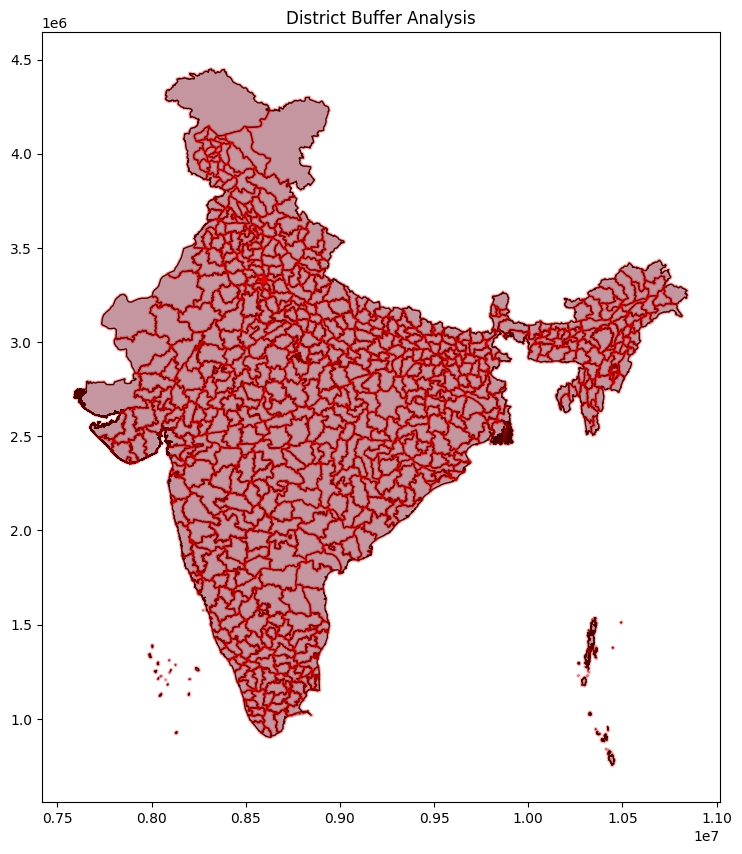

In [6]:
fig, ax = plt.subplots(figsize=(10,10))

gdf_projected.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black"
)

buffered.plot(
    ax=ax,
    color="red",
    alpha=0.3
)
plt.title("District Buffer Analysis")
plt.show()

In [7]:
intersection = gpd.overlay(
    gdf_projected,
    gdf_projected,
    how="intersection"
)

intersection.head()

d:\Codes\Global Venv\venv\lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 5284 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


,DISTRICT_1,ST_NM_1,ST_CEN_CD_1,DT_CEN_CD_1,censuscode_1,mean_value_1,min_value_1,max_value_1,DISTRICT_2,ST_NM_2,ST_CEN_CD_2,DT_CEN_CD_2,censuscode_2,mean_value_2,min_value_2,max_value_2,geometry
0,Adilabad,Andhra Pradesh,28,1,532,6.529690,0.0,60.000000,Adilabad,Andhra Pradesh,28,1,532,6.529690,0.0,60.000000,"POLYGON ((8777654.973 2244556.06, 8778541.427 ..."
1,Agra,Uttar Pradesh,9,15,146,2.728956,0.0,51.683168,Agra,Uttar Pradesh,9,15,146,2.728956,0.0,51.683168,"POLYGON ((8704965.516 3173885.153, 8706179.785..."
2,Ahmadabad,Gujarat,24,7,474,7.783338,0.0,60.000000,Ahmadabad,Gujarat,24,7,474,7.783338,0.0,60.000000,"MULTIPOLYGON (((8018718.02 2692028.76, 8018392..."
3,Ahmadabad,Gujarat,24,7,474,7.783338,0.0,60.000000,Anand,Gujarat,24,15,482,5.330468,0.0,60.000000,"POLYGON ((8071588.341 2585505.23, 8071588.34 2..."
4,Ahmadabad,Gujarat,24,7,474,7.783338,0.0,60.000000,Kheda,Gujarat,24,16,483,1.629955,0.0,60.000000,"POLYGON ((8071588.34 2585505.238, 8071588.34 2..."


In [8]:
union_result = gpd.overlay(
    gdf_projected,
    gdf_projected,
    how="union"
)

union_result.head()

d:\Codes\Global Venv\venv\lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 5288 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


,DISTRICT_1,ST_NM_1,ST_CEN_CD_1,DT_CEN_CD_1,censuscode_1,mean_value_1,min_value_1,max_value_1,DISTRICT_2,ST_NM_2,ST_CEN_CD_2,DT_CEN_CD_2,censuscode_2,mean_value_2,min_value_2,max_value_2,geometry
0,Adilabad,Andhra Pradesh,28.0,1.0,532.0,6.529690,0.0,60.000000,Adilabad,Andhra Pradesh,28.0,1.0,532.0,6.529690,0.0,60.000000,"POLYGON ((8777654.973 2244556.06, 8778541.427 ..."
1,Agra,Uttar Pradesh,9.0,15.0,146.0,2.728956,0.0,51.683168,Agra,Uttar Pradesh,9.0,15.0,146.0,2.728956,0.0,51.683168,"POLYGON ((8704965.516 3173885.153, 8706179.785..."
2,Ahmadabad,Gujarat,24.0,7.0,474.0,7.783338,0.0,60.000000,Ahmadabad,Gujarat,24.0,7.0,474.0,7.783338,0.0,60.000000,"MULTIPOLYGON (((8018718.02 2692028.76, 8018392..."
3,Ahmadabad,Gujarat,24.0,7.0,474.0,7.783338,0.0,60.000000,Anand,Gujarat,24.0,15.0,482.0,5.330468,0.0,60.000000,"POLYGON ((8071588.341 2585505.23, 8071588.34 2..."
4,Ahmadabad,Gujarat,24.0,7.0,474.0,7.783338,0.0,60.000000,Kheda,Gujarat,24.0,16.0,483.0,1.629955,0.0,60.000000,"POLYGON ((8071588.34 2585505.238, 8071588.34 2..."


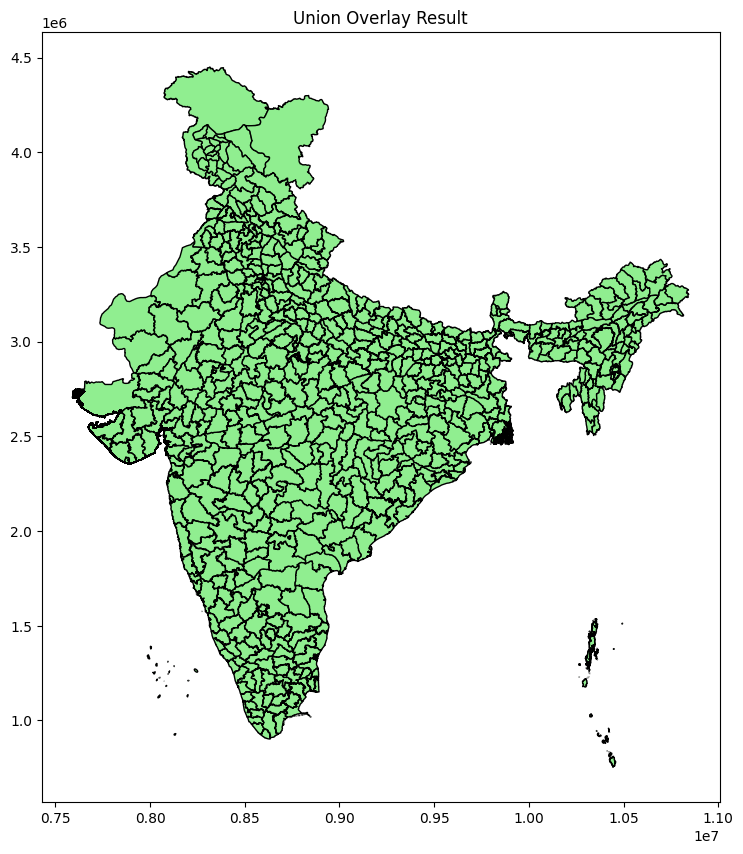

In [9]:
union_result.plot(
    figsize=(10,10),
    color="lightgreen",
    edgecolor="black"
)

plt.title("Union Overlay Result")

plt.show()

In [10]:
rajasthan = gdf[   # attribute query to filter Rajasthan district and can be done for any other state by changing the name in the query
    gdf["ST_NM"] == "Rajasthan"
]
rajasthan.head()

,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,mean_value,min_value,max_value,geometry
5,Ajmer,Rajasthan,8,21,119,1.475725,0.0,60.000000,"MULTIPOLYGON (((74.89253 26.97702, 74.90465 26..."
12,Alwar,Rajasthan,8,6,104,0.610539,0.0,60.000000,"MULTIPOLYGON (((76.86341 28.22005, 76.8668 28...."
49,Banswara,Rajasthan,8,27,125,0.712294,0.0,51.683168,"POLYGON ((74.49053 23.90931, 74.49327 23.90164..."
53,Baran,Rajasthan,8,30,128,0.769455,0.0,51.683168,"POLYGON ((76.71961 25.33754, 76.7219 25.33396,..."
56,Barmer,Rajasthan,8,17,115,37.691350,0.0,60.000000,"POLYGON ((72.07268 26.34943, 72.08514 26.33629..."


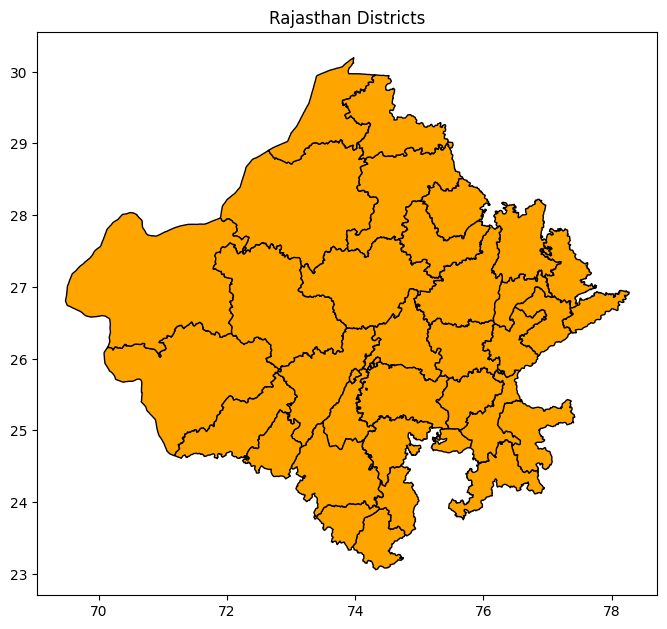

In [11]:
rajasthan.plot(
    figsize=(8,8),
    color="orange",
    edgecolor="black"
)

plt.title("Rajasthan Districts")

plt.show()

In [12]:
touching = gdf[               # which districts are touching Rajasthan
    gdf.touches(rajasthan.unary_union)
]
touching.head()

C:\Users\naman\AppData\Local\Temp\ipykernel_11284\268578956.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf.touches(rajasthan.unary_union)


,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,mean_value,min_value,max_value,geometry
1,Agra,Uttar Pradesh,9,15,146,2.728956,0.0,51.683168,"POLYGON ((78.19803 27.4028, 78.19804 27.40278,..."
42,Banas Kantha,Gujarat,24,2,469,1.791690,0.0,60.000000,"POLYGON ((72.26847 24.62413, 72.26909 24.62423..."
181,Fatehabad,Haryana,6,10,78,0.586727,0.0,60.000000,"POLYGON ((75.9494 29.73013, 75.94831 29.71824,..."
209,Guna,Madhya Pradesh,23,41,458,0.866620,0.0,51.683168,"POLYGON ((77.30839 25.07887, 77.30862 25.07411..."
227,Hisar,Haryana,6,12,80,1.108984,0.0,60.000000,"POLYGON ((75.95991 29.56546, 75.96242 29.55161..."


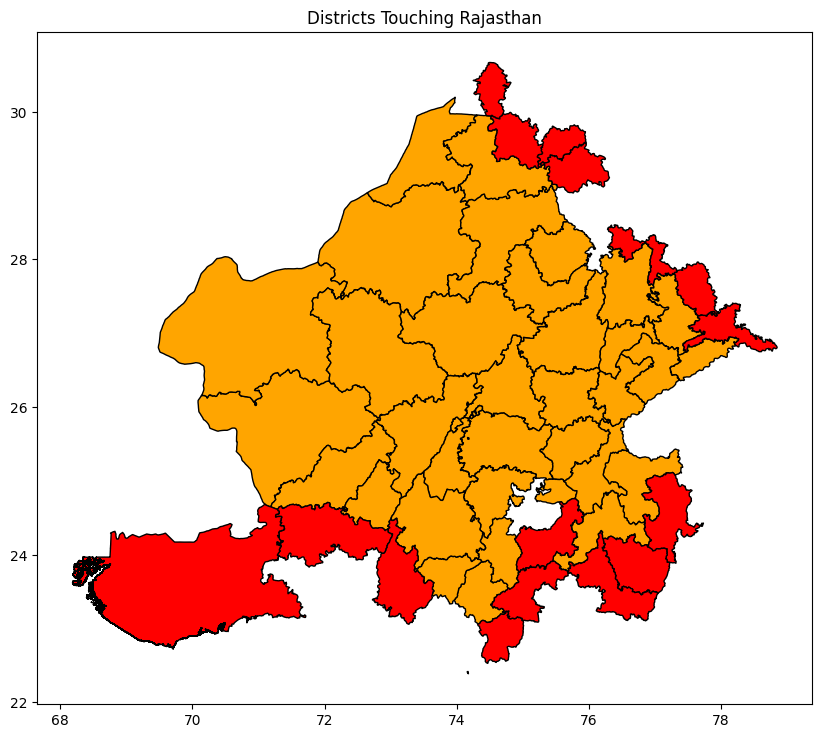

In [13]:
fig, ax = plt.subplots(figsize=(10,10))

rajasthan.plot(
    ax=ax,
    color="orange",
    edgecolor="black"

)

touching.plot(
    ax=ax,
    color="red",
    edgecolor="black"

)

plt.title("Districts Touching Rajasthan")
plt.show()